## **Importação das bibliotecas e dados (AEP e Duas Unas)**

In [389]:
# %pip install ipykernel --break-system-packages
# %pip install scikit-learn --break-system-packages
# %pip install matplotlib --break-system-packages
# %pip install keras --break-system-packages
# %pip install tensorflow --break-system-packages
# %pip install pandas --break-system-packages
# %pip install plotly --break-system-packages
# %pip install seaborn --break-system-packages
# %pip install nbformat --break-system-packages
# %pip install keras --break-system-packages
# %pip install pswarm
%pip install openpyxl --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [390]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

base_path = './dataset/'
time_base = 'days'
duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_1_{time_base}.csv'
volume_dataset = f'{base_path}volume/volume.xlsx'
validation_interval = 61
time_step = 1
output_steps = 60

In [391]:
duas_unas_df = pd.read_csv(duas_unas_dataset)

volume_df = pd.read_excel(volume_dataset)

duas_unas_df['timestamp'] = pd.to_datetime(duas_unas_df['timestamp'], errors='coerce')

volume_df['DATA'] = pd.to_datetime(volume_df['DATA'], errors='coerce')

merged_df = pd.merge(duas_unas_df, volume_df, left_on='timestamp', right_on='DATA', how='inner')

final_df = merged_df[['timestamp', 'kWh fornecido', 'DUAS UNAS']].rename(columns={
    'kWh fornecido': 'kwh',
    'DUAS UNAS': 'cota'
})

final_df['timestamp'] = final_df['timestamp'].dt.strftime('%Y%m%d').astype(int)

print(final_df)
X = final_df[['timestamp', 'cota']]
y = final_df['kwh']

left_merge = pd.merge(volume_df, duas_unas_df, left_on='DATA', right_on='timestamp', how='left', indicator=True)

missing_volume_data = left_merge[left_merge['_merge'] == 'left_only']

missing_volume_final = missing_volume_data[['DATA', 'DUAS UNAS']].rename(columns={
    'DATA': 'timestamp',
    'DUAS UNAS': 'cota'
})

missing_volume_final = missing_volume_final[missing_volume_final['timestamp'].notna()]

missing_volume_final['timestamp'] = missing_volume_final['timestamp'].dt.strftime('%Y%m%d').astype(int)

print(missing_volume_final)



     timestamp       kwh   cota
0     20231001      0.00   69.9
1     20231002      0.00  69.88
2     20231003      0.00  69.87
3     20231004      0.00   69.8
4     20231005  10827.36  69.84
..         ...       ...    ...
278   20240705  22425.48  69.97
279   20240706  22914.36  69.97
280   20240707  22919.40  70.03
281   20240708  22861.44  70.08
282   20240709  22837.68  70.02

[283 rows x 3 columns]
      timestamp   cota
1      20090624  70.02
2      20090625  70.01
3      20090626     70
4      20090627     70
5      20090628  69.99
...         ...    ...
5206   20230926  69.98
5207   20230927  69.98
5208   20230928  69.95
5209   20230929   69.9
5210   20230930   69.9

[5210 rows x 2 columns]


In [392]:
# duas_unas_validation = duas_unas_df.tail(validation_interval)  

# indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  
# duas_unas_df = duas_unas_df.drop(indices_to_validate).reset_index(drop=True)  

# duas_unas_df['timestamp'] = pd.to_datetime(duas_unas_df['timestamp'])  
# duas_unas_validation['timestamp'] = pd.to_datetime(duas_unas_validation['timestamp'])  

# duas_unas_df['index'] = range(len(duas_unas_df))  
# duas_unas_validation['index'] = indices_to_validate  
# duas_unas_df['kwh'] = duas_unas_df['kWh fornecido']  
# duas_unas_validation['kwh'] = duas_unas_validation['kWh fornecido']  

# # duas_unas_df.drop(columns=['timestamp'], inplace=True) 
# # duas_unas_validation.drop(columns=['timestamp'], inplace=True)  

# # duas_unas_df.drop(columns=['kWh fornecido'], inplace=True)  
# # duas_unas_validation.drop(columns=['kWh fornecido'], inplace=True)  

# X = duas_unas_df['index'].values.reshape(-1,1)
# y = duas_unas_df['kwh'].values  

# X_validation = duas_unas_validation['index'].values.reshape(-1,1)  
# y_validation = duas_unas_validation['kwh'].values

In [393]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.65, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=1)

In [394]:
y_pred = knn.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'rmse: {rmse:.2f}')

rmse: 3469.66


In [395]:
missing_volume_final = missing_volume_final[['timestamp', 'cota']].tail(1080)
valid_df_missing = scaler.transform(missing_volume_final)
y_pred_validation = knn.predict(valid_df_missing)

In [396]:
# validation_df = scaler.transform(final_df_validation[['timestamp', 'cota']])
# y_pred_validation = knn.predict(validation_df)
# print(y_pred_validation)

      timestamp   cota       kwh
4131   20201016  65.91  21084.84
4132   20201017  65.91  21084.84
4133   20201018  65.83  21084.84
4134   20201019   65.8  21084.84
4135   20201020  65.75  21084.84
...         ...    ...       ...
5206   20230926  69.98  12201.48
5207   20230927  69.98  12201.48
5208   20230928  69.95  12201.48
5209   20230929   69.9  12201.48
5210   20230930   69.9  12201.48

[1080 rows x 3 columns]


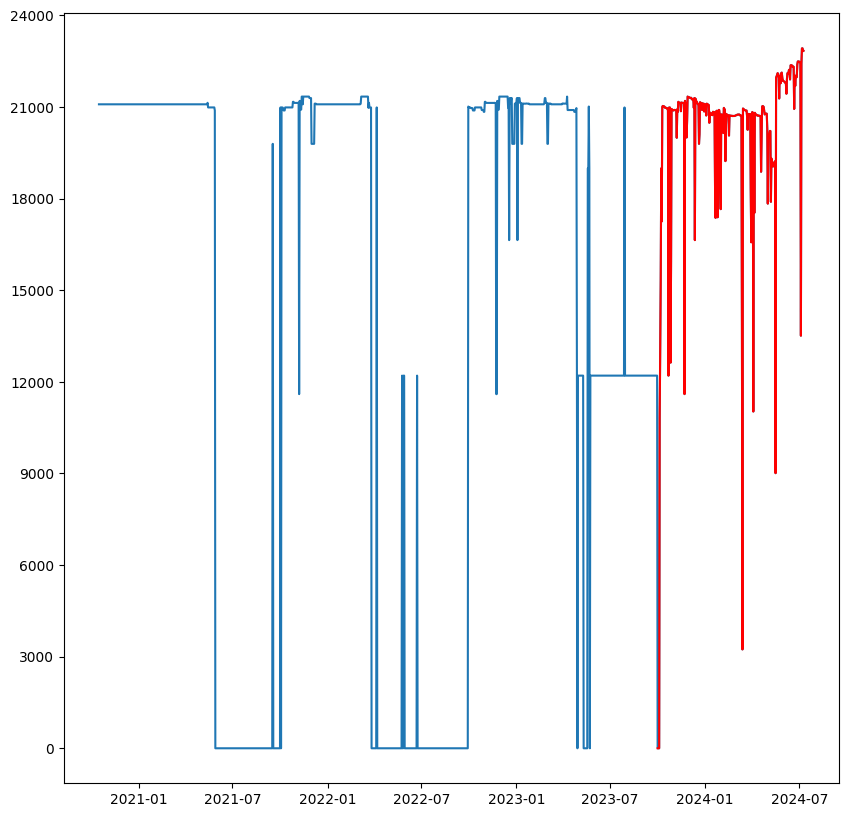

In [398]:
predict_validation_kwh = missing_volume_final.copy()
predict_validation_kwh['kwh'] = y_pred_validation
print(predict_validation_kwh)

predict_validation_kwh['timestamp'] = pd.to_datetime(predict_validation_kwh['timestamp'], format='%Y%m%d', errors='coerce')
final_df['timestamp'] = pd.to_datetime(final_df['timestamp'], format='%Y%m%d', errors='coerce')
# df_periodo = missing_volume_final[(missing_volume_final['timestamp'].dt.year >=2021)]
df_periodo = pd.concat([predict_validation_kwh, final_df])

plt.figure(figsize=(10,10))
plt.plot(df_periodo['timestamp'], df_periodo['kwh'])
plt.plot(final_df['timestamp'], final_df['kwh'], color= 'red')
plt.yticks(np.arange(0,25000,step=3000))
plt.show()
